# #9 Time Series - Business Forecasting with Prophet

End-to-end Prophet forecasting project on synthetic e-commerce sales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
np.random.seed(42)


## Generate synthetic data

In [2]:
dates=pd.date_range('2020-01-01',periods=1460,freq='D')
trend=np.linspace(200,420,len(dates))
weekly=25*np.sin(2*np.pi*np.arange(len(dates))/7)
yearly=35*np.sin(2*np.pi*np.arange(len(dates))/365)
noise=np.random.normal(0,8,len(dates))
sales=trend+weekly+yearly+noise
for s,e,b in [('2021-05-10','2021-05-20',35),('2022-10-01','2022-10-15',45),('2023-06-01','2023-06-12',40)]:
    m=(dates>=s)&(dates<=e)
    sales[m]+=b
for y in [2020,2021,2022,2023]:
    sales[(dates>=f'{y}-12-20')&(dates<=f'{y}-12-27')]+=80
    sales[dates==pd.Timestamp(f'{y}-11-26')]+=120
sales[dates>='2022-07-01']+=np.linspace(0,120,(dates>='2022-07-01').sum())
df=pd.DataFrame({'ds':dates,'y':sales})
df.head()


,ds,y
0,2020-01-01,203.973713
1,2020-01-02,219.192928
2,2020-01-03,231.061039
3,2020-01-04,225.290385
4,2020-01-05,190.290917


## Visualize

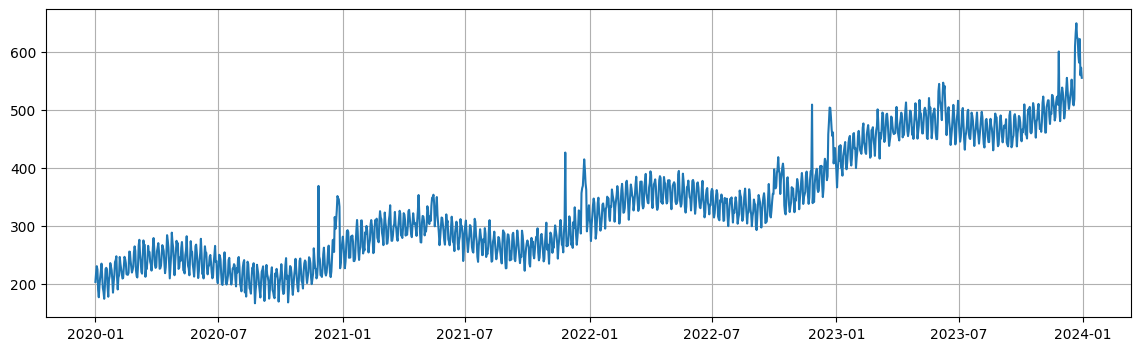

In [3]:
plt.figure(figsize=(14,4))
plt.plot(df.ds,df.y)
plt.grid(True)
plt.show()

## Holidays

In [4]:
holidays=pd.DataFrame({
'holiday':['christmas','black_friday','anniversary'],
'ds':pd.to_datetime(['2020-12-25','2021-11-26','2023-08-15']),
'lower_window':[0,0,0],
'upper_window':[2,1,3]
})
holidays

,holiday,ds,lower_window,upper_window
0,christmas,2020-12-25,0,2
1,black_friday,2021-11-26,0,1
2,anniversary,2023-08-15,0,3


## Train/Test

In [5]:
train=df.iloc[:-90]
test=df.iloc[-90:]

## Fit Prophet

In [6]:
model=Prophet(yearly_seasonality=True,
weekly_seasonality=True,
daily_seasonality=False,
holidays=holidays,
changepoint_prior_scale=0.15)
model.fit(train)


## Forecast

In [7]:
future=model.make_future_dataframe(periods=90)
forecast=model.predict(future)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1455,2023-12-26,545.914376,527.791623,562.632917
1456,2023-12-27,564.826354,548.111322,582.757565
1457,2023-12-28,584.764324,568.904184,600.812041
1458,2023-12-29,587.057685,570.623133,606.248837
1459,2023-12-30,575.107004,556.851525,590.292022


## Forecast Plot

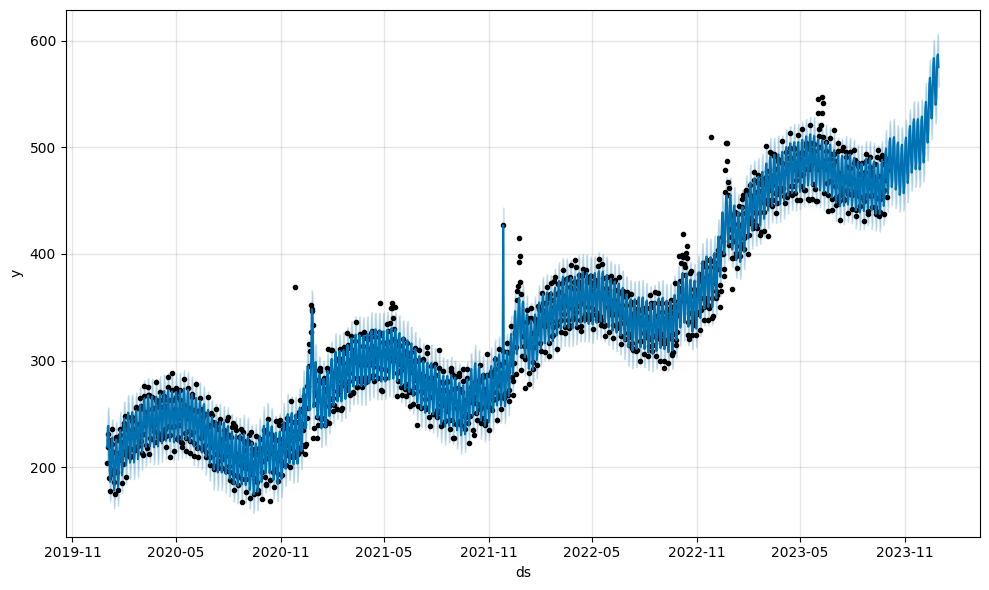

In [8]:
model.plot(forecast)
plt.grid(True)
plt.show()

## Components

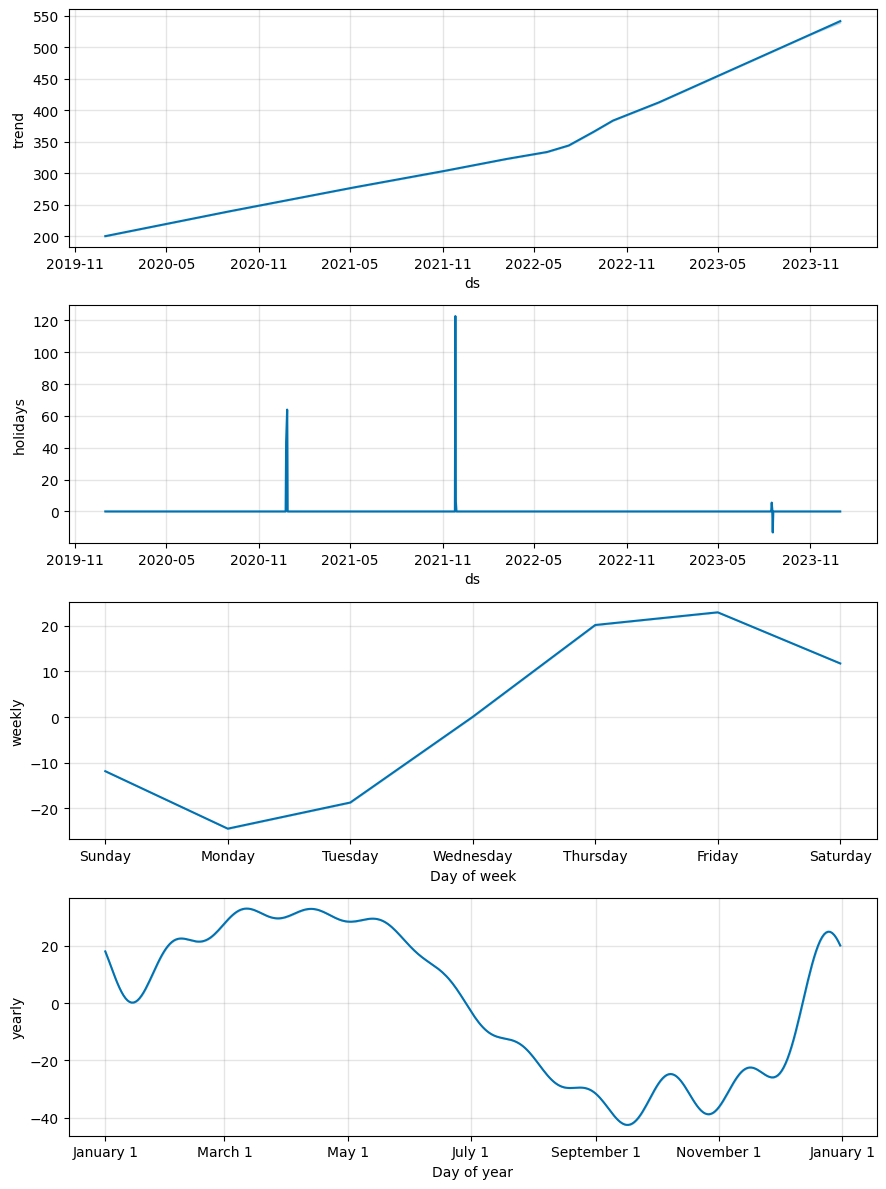

In [9]:
model.plot_components(forecast)
plt.show()

## Metrics

In [10]:
pred=forecast[['ds','yhat']].tail(90).set_index('ds')
actual=test.set_index('ds')
mae=mean_absolute_error(actual.y,pred.yhat)
rmse=np.sqrt(mean_squared_error(actual.y,pred.yhat))
mape=np.mean(np.abs((actual.y-pred.yhat)/actual.y))*100
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: 13.81
RMSE: 22.94
MAPE: 2.52%


## Cross Validation (optional)

In [11]:
df_cv=cross_validation(model,initial='730 days',period='180 days',horizon='90 days')
performance_metrics(df_cv).head()

INFO:prophet:Making 4 forecasts with cutoffs between 2022-01-09 00:00:00 and 2023-07-03 00:00:00


  0%|          | 0/4 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,98.152849,9.907212,7.507576,0.020013,0.016492,0.019891,0.916667
1,10 days,103.936842,10.194942,7.654263,0.019651,0.016430,0.019557,0.888889
2,11 days,69.588057,8.341946,6.585142,0.016818,0.011966,0.016829,0.916667
3,12 days,84.432034,9.188691,7.323214,0.018629,0.016430,0.018686,0.861111
4,13 days,86.372739,9.293693,7.404631,0.019006,0.016430,0.019056,0.861111


# Conclusions

- Trend, holidays and multiple seasonalities are modeled automatically.
- Prophet is well suited to business forecasting.
- Try changing changepoint_prior_scale and adding custom regressors.